# Calculate Properties of Transmission Lines

## Calculate Propagation Constant by measuring input impedances

In general, a load connected to a lossless transmission will have input impedance given by:
$$Z_{in} = Z_0 \frac{Z_L + j Z_0 \tan(\beta l)}{Z_0 + j Z_L \tan(\beta l)}$$
where $Z_0$ is the characteristic impedance of the line, $Z_L$ is the load impedance.

By measuring the impedance of a certain length of cable, we can calculate the propagation constant $\beta$ of the line. 

On Smith chart, it's more convenient to think of reflection coefficient $\Gamma$ instead of impedance. The reflection coefficient at the interface between the line and the load is given by:
$$\Gamma = \frac{Z_L - Z_0}{Z_L + Z_0}$$
The reflection coefficient at the input of the line can be expressed as:
$$\Gamma_{in} = \Gamma e^{-j 2 \beta l}$$

Most of the functions used in this notebook can be found in https://scikit-rf.readthedocs.io/en/latest/api/tlineFunctions.html. 

In [3]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
from matplotlib import pyplot as plt
import skrf as rf

from highz_exp.s_params import S_Params

Using the measured impedance of a 8' long coax cable terminated with a 99 Ohm load, we can calculate the propagation constant $\beta$ of the line. 

In [9]:
data_path = pjoin(os.getcwd(), '../data')

# measured input impedance of 99 Ohm load at the end of an 8' cable
measured_99 = rf.Network(pjoin(data_path, '99OHM.S1P'))

# frequency axis
chosen_f = measured_99.f
d = 2.4384 # meters, 8 feet long cable
z_0 = 50
r_l = 99
z_in = measured_99.z[:, 0, 0]
gamma_load = rf.tlineFunctions.zl_2_Gamma0(z_0, r_l)

gamma_in =  rf.tlineFunctions.zl_2_Gamma0(z_0, measured_99.z[:, 0, 0]) # at input
prop_cst = rf.tlineFunctions.reflection_coefficient_2_propagation_constant(gamma_in, gamma_load, d)

reproduced_z = rf.tlineFunctions.zl_2_zin(z_0, r_l, theta=prop_cst * d)
reproduced_ntwk = rf.Network(f=chosen_f, z0=z_0, 
    z=reproduced_z[:, np.newaxis, np.newaxis])

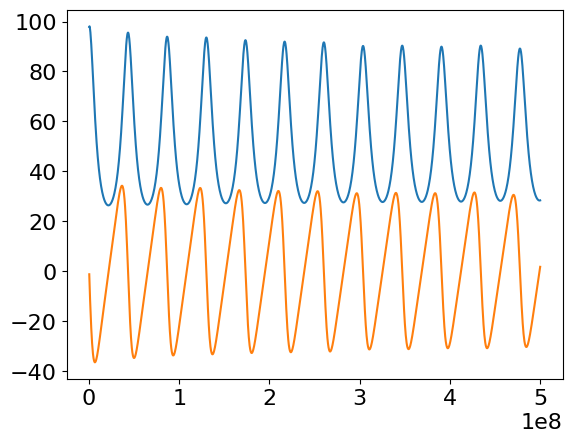

In [11]:
# Plot reproduced impedance real and imaginary parts
plt.plot(chosen_f, reproduced_z.real, label='Measured Real')
plt.plot(chosen_f, reproduced_z.imag, label='Measured Imag')

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

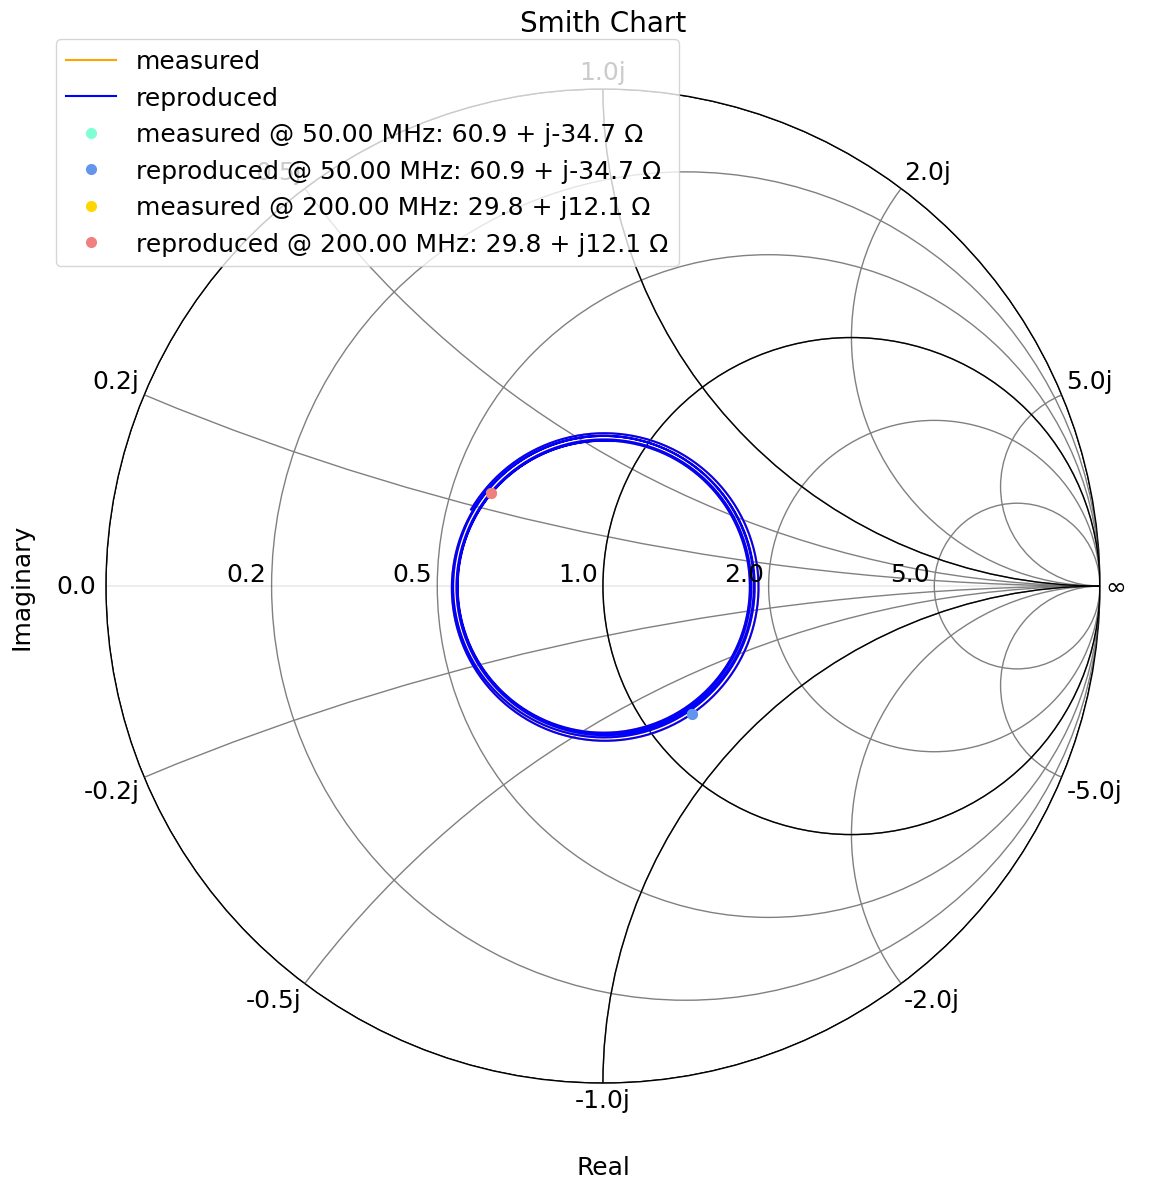

In [13]:
# Compare reproduced and measured input impedance
compare = S_Params(ntwk_dict={
    'measured': measured_99,
    'reproduced': reproduced_ntwk}, colorcode=['orange', 'blue'])
compare.plot_smith_chart(marker_freqs=[50e6, 200e6], freq_range=(25, 250))

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

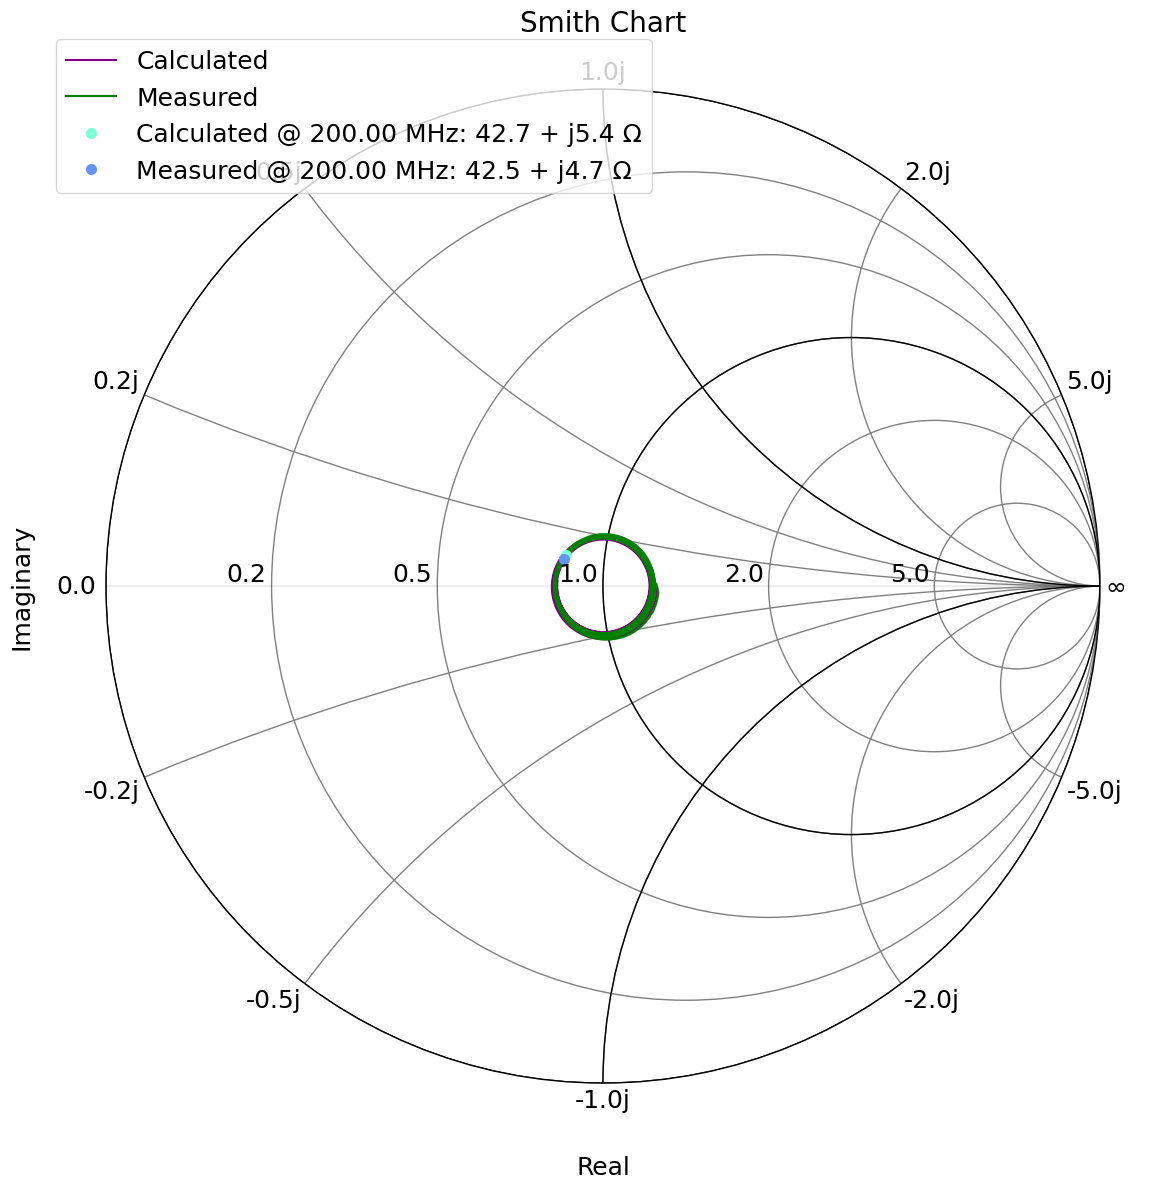

In [22]:
# Test on a different load value
measured_62 = rf.Network(pjoin(data_path, '62OHM.S1P'))
r_l_test = 62.3
test_impd = rf.tlineFunctions.zl_2_zin(z_0, r_l_test, theta=prop_cst * d)

test_ntwk = rf.Network(f=measured_62.f, z0=z_0, z=test_impd[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': measured_62}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[200e6])

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

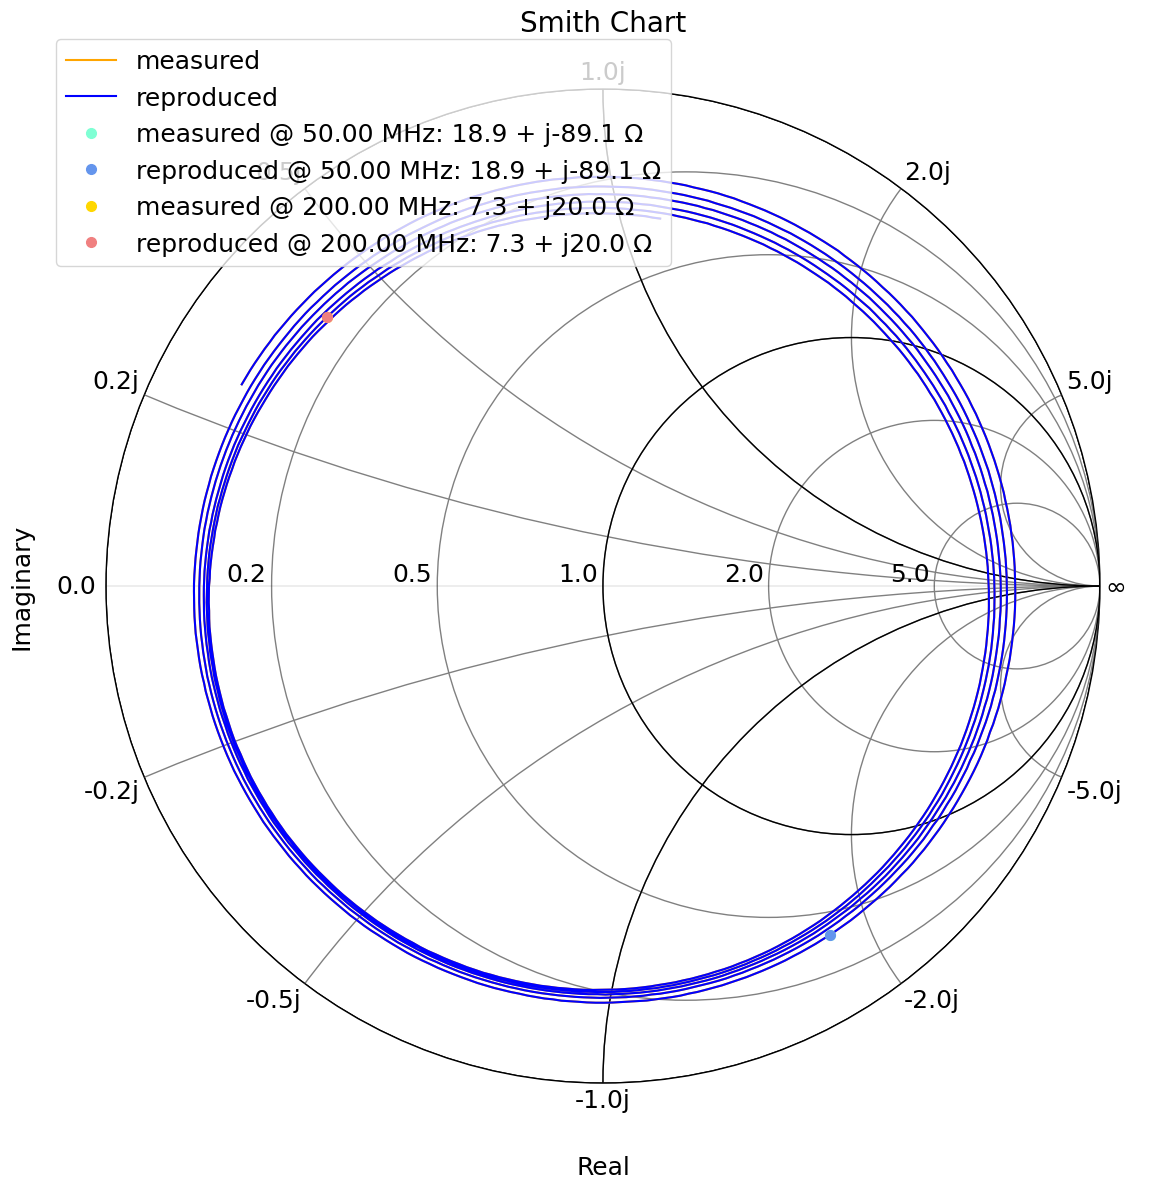

In [23]:
# measured input impedance of 699 Ohm load at the end of an 8" cable
measured_699 = rf.Network(pjoin(data_path, '699OHM.S1P'))

# frequency axis
chosen_f = measured_699.f
d = 2.4384 # meters, 8 feet long cable
z_0 = 50
r_l = 699
z_in = measured_699.z[:, 0, 0]
gamma_load = rf.tlineFunctions.zl_2_Gamma0(z_0, r_l)

gamma_in =  rf.tlineFunctions.zl_2_Gamma0(z_0, measured_699.z[:, 0, 0]) # at input
prop_cst = rf.tlineFunctions.reflection_coefficient_2_propagation_constant(gamma_in, gamma_load, d)

reproduced_z = rf.tlineFunctions.zl_2_zin(z_0, r_l, theta=prop_cst * d)
reproduced_ntwk = rf.Network(f=chosen_f, z0=z_0, 
    z=reproduced_z[:, np.newaxis, np.newaxis])

# Compare reproduced and measured input impedance
compare = S_Params(ntwk_dict={
    'measured': measured_699,
    'reproduced': reproduced_ntwk}, colorcode=['orange', 'blue'])
compare.plot_smith_chart(marker_freqs=[50e6, 200e6], freq_range=(25, 250))

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

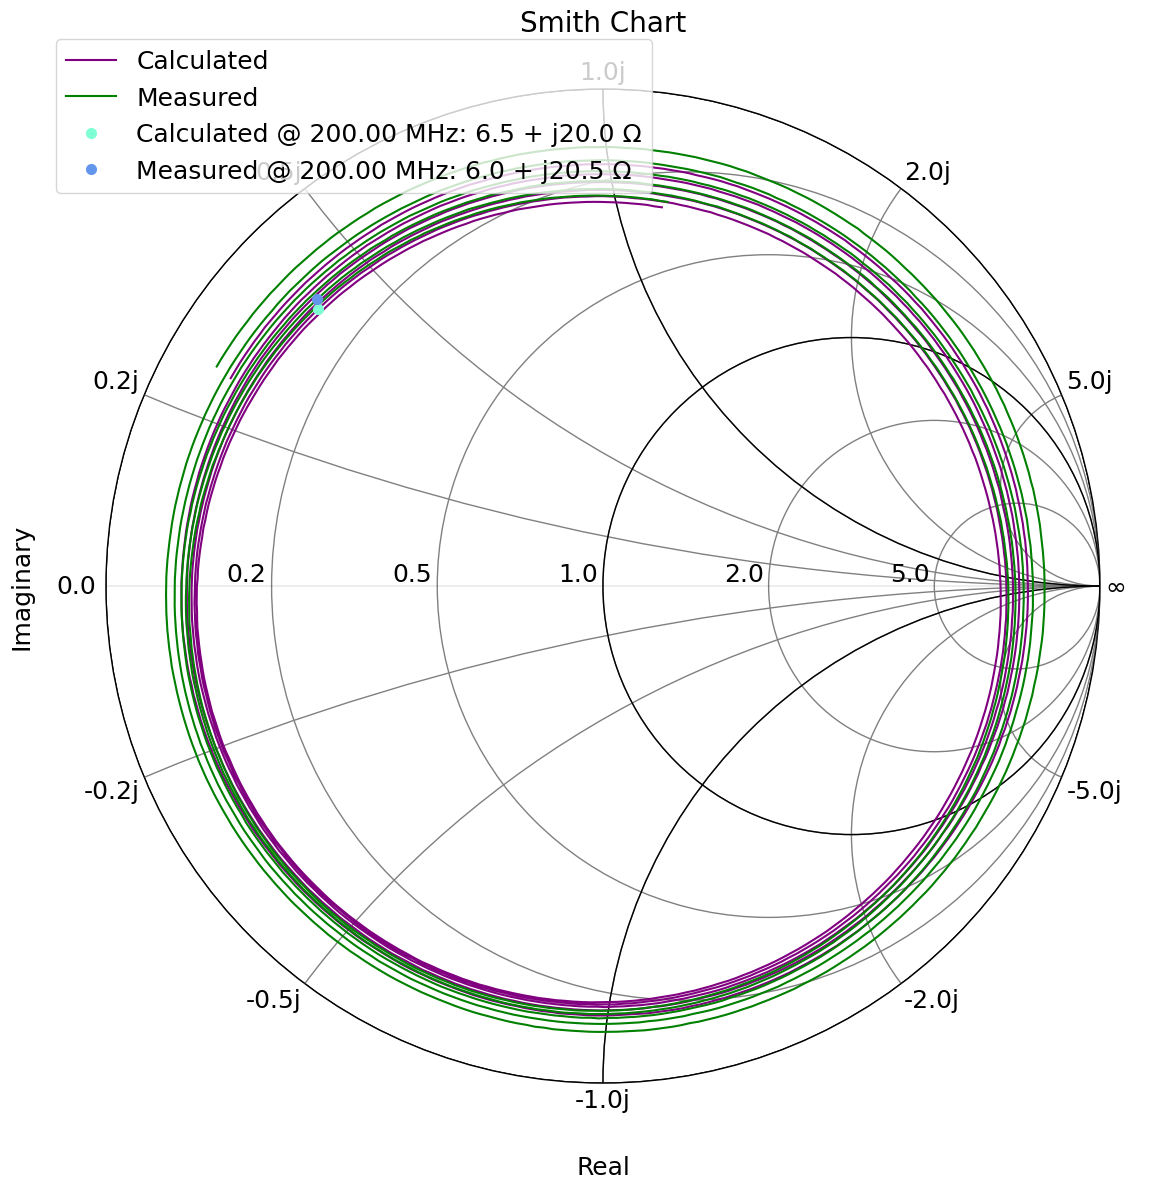

In [ ]:
# Test on a different load value
measured_885 = rf.Network(pjoin(data_path, '885OHM.S1P'))
r_l_test = 885.0
test_impd = rf.tlineFunctions.zl_2_zin(z_0, r_l_test, theta=prop_cst * (d+1))

test_ntwk = rf.Network(f=measured_885.f, z0=z_0, z=test_impd[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': measured_885}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[200e6])

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

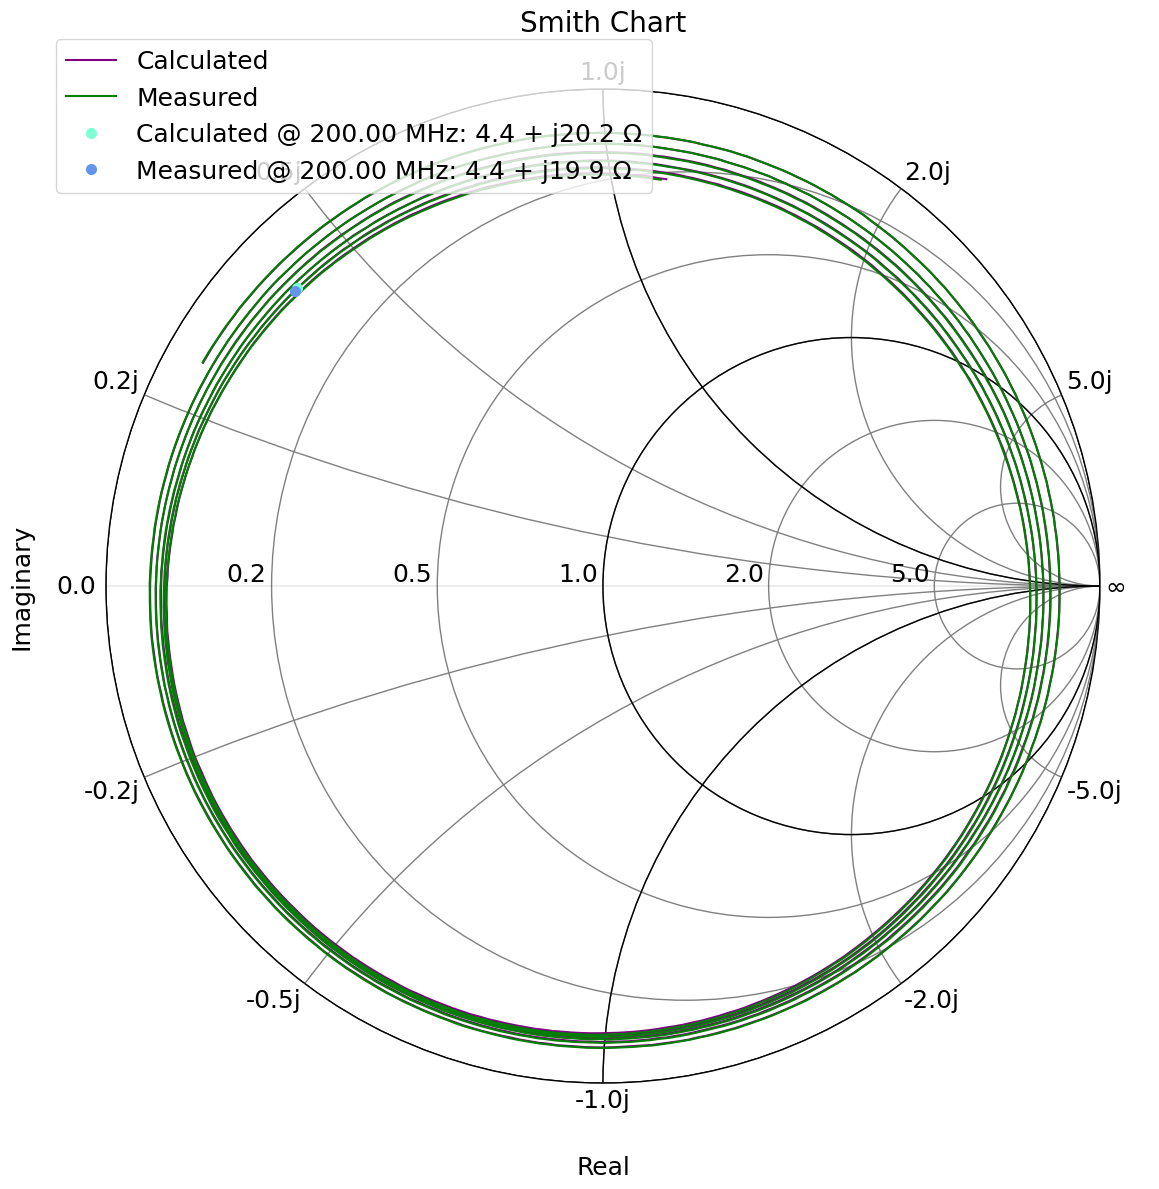

In [ ]:
# Test by applying propagation constant on a different load value
measured_2413 = rf.Network(pjoin(data_path, '2413OHM.S1P'))
r_l_test = 2413.0
test_impd = rf.tlineFunctions.zl_2_zin(z_0, r_l_test, theta=prop_cst * d)

test_ntwk = rf.Network(f=measured_2413.f, z0=z_0, z=test_impd[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': measured_2413}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[200e6])

## Special Cases: Long cable with short circuit or open circuit terminations

(<Figure size 1400x1200 with 1 Axes>,
 <Axes: title={'center': 'Smith Chart'}, xlabel='Real', ylabel='Imaginary'>)

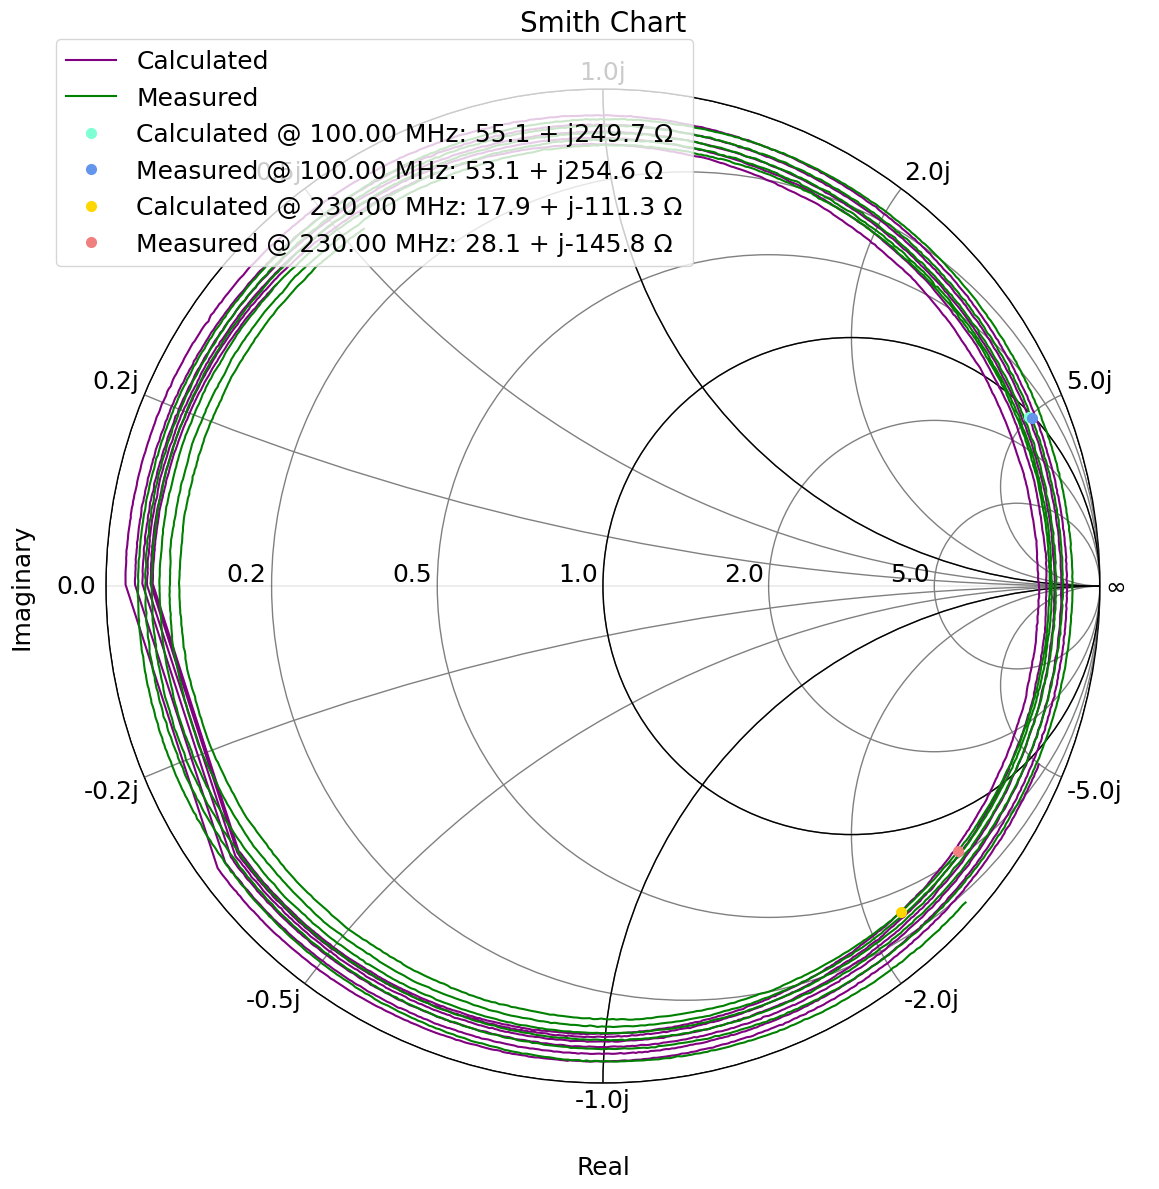

In [21]:
# Calculate propagation constant by using open and short circuited cables
cal_s11 = S_Params(pickle_file=pjoin(data_path, 'all_S11s.pkl'))
_ = cal_s11.keep_freq(25e6, 250e6)

measured_open = cal_s11.ntwk_dict["8' cable open"]
# frequency axis
chosen_f = measured_open.f
d = 2.4384 # meters, 8 feet long cable
z_0 = 50
z_in = measured_open.z[:, 0, 0]
gamma_load = 1

gamma_in =  rf.tlineFunctions.zl_2_Gamma0(z_0, z_in) # at input
prop_cst = rf.tlineFunctions.reflection_coefficient_2_propagation_constant(gamma_in, gamma_load, d)

# Test on short
measured_short = cal_s11.ntwk_dict["8' cable short"]
gamma_load = -1
gamma_in = rf.tlineFunctions.Gamma0_2_Gamma_in(gamma_load, theta=prop_cst * d * 0.9)

test_ntwk = rf.Network(f=measured_short.f, z0=z_0, s=gamma_in[:, np.newaxis, np.newaxis])
comparison = S_Params(ntwk_dict={'Calculated': test_ntwk, 'Measured': measured_short}, 
                      colorcode=['purple', 'green'])
comparison.plot_smith_chart(marker_freqs=[100e6, 230e6])

### References:
- [Determination of the propagation constant from the input impedance](https://scikit-rf.readthedocs.io/en/latest/examples/networktheory/Transmission%20Line%20Properties%20and%20Manipulations.html#Determination-of-the-propagation-constant-from-the-input-impedance)
- Chapter 2. Pozar, D. M. (2011). Microwave engineering (4th ed.). Wiley.